Import de dataset y librerias

In [ ]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from skforecast.preprocessing import RollingFeatures

dataset = 'Lorca_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'pressure_sensor','month', 'day', 'hour', 'minute']


Dividimos en train y test

In [8]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Escalamos los datos.

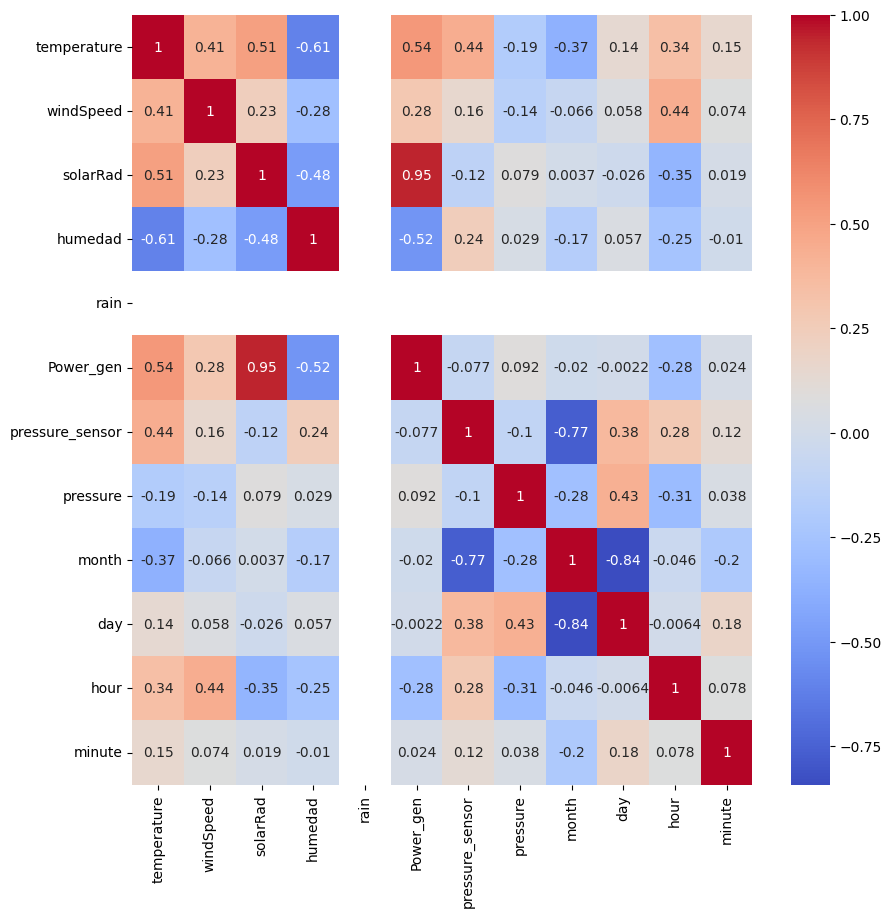

In [9]:
scaler = MinMaxScaler()
#entrenamiento
train_scaled = data_train.copy()
train_scaled[exogenas] = scaler.fit_transform(data_train[exogenas])

corr_df = train_scaled.corr(method ='spearman')

#test
test_scaled = data_test.copy()
test_scaled[exogenas] = scaler.fit_transform(data_test[exogenas])

corr_df = test_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Evolucion de las variables exogenas

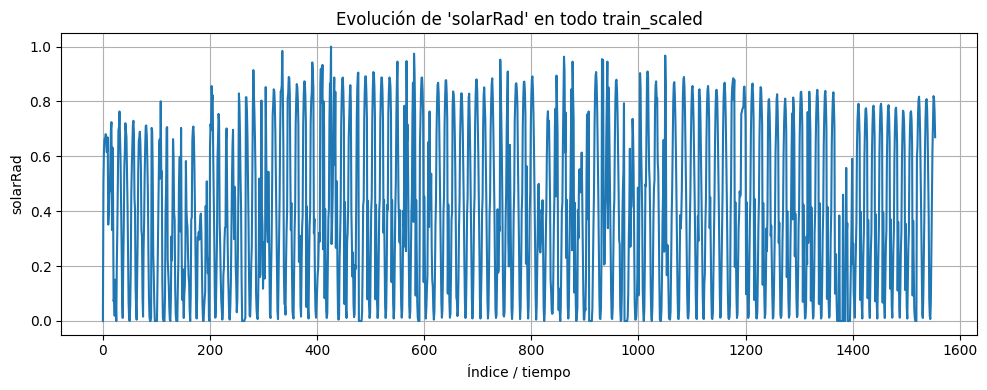

In [10]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index, train_scaled[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo train_scaled")
plt.grid(True)
plt.tight_layout()
plt.show()


Valores de las exogenas para un dia en concreto

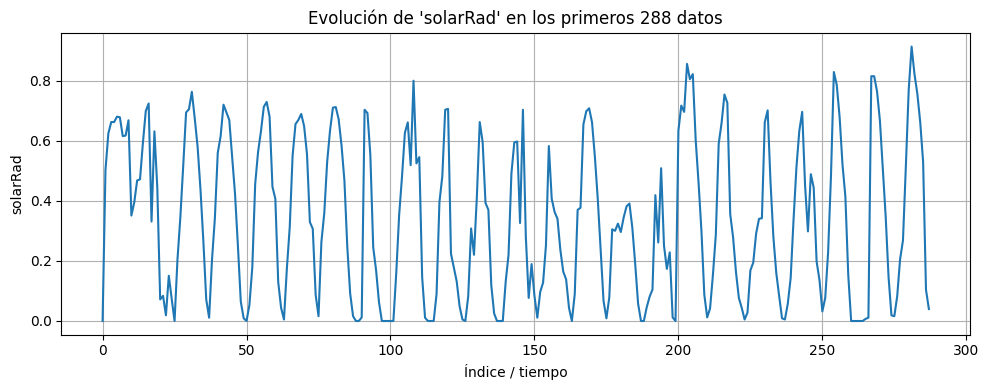

In [11]:
pasos_dia = (24 * 60 // 5)   #288 primer dia de data_train (datos cada 5 minutos)

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index[:pasos_dia], train_scaled[var].iloc[:pasos_dia])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en los primeros {pasos_dia} datos")
plt.grid(True)
plt.tight_layout()
plt.show()

El primer paso es crear el forecaster.

In [12]:
window_features = RollingFeatures(
                      stats        = ['mean', 'min', 'max'],
                      window_sizes = [10, 10, 10]
                  )

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 5, n_estimators = 400, subsample = 0.8),
    lags = 3,
    window_features = window_features
)

Entrenamos el forecaster

In [ ]:
X_test, y_test = forecaster.create_train_X_y(y=test_scaled['Power_gen'], exog=test_scaled[exogenas])
X_train, y_train = forecaster.create_train_X_y(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

forecaster.fit(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])
forecaster

Comprobamos si hay overfitting. El early_stop = None, por lo que se aplicará sobre los 900 árboles. La reducción del error segun avanza el train indica la efectiva eliminacion de perdidas. Alcanza unaestabilización al final, lo que significa el final del proceso de entrenamiento. El comportamiento del modelo en entrenamiento y validacion es consistente, lo que confirma la no presencia de sobreentrenamiento en los datos.

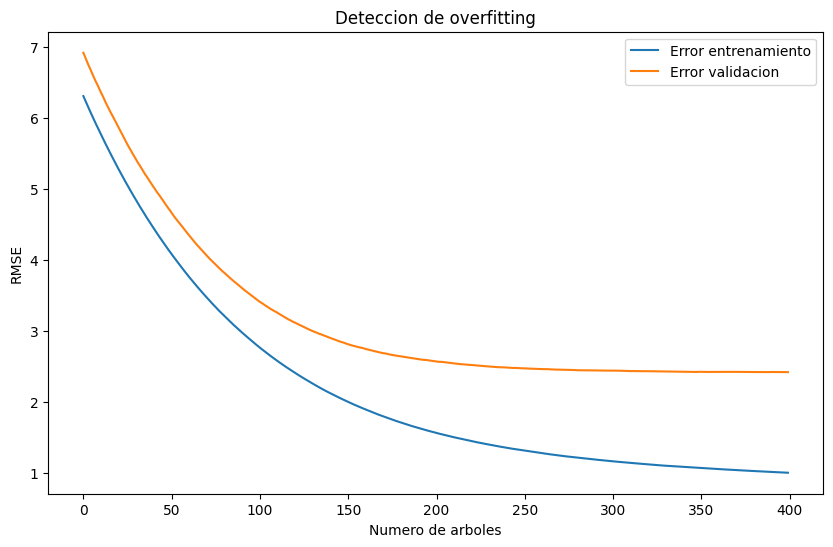

In [ ]:
model  = forecaster.estimator

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)

results = model.evals_result()

plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['rmse'], label='Error entrenamiento')
plt.plot(results['validation_1']['rmse'], label='Error validacion')
plt.xlabel('Numero de arboles')
plt.ylabel('RMSE')
plt.title('Deteccion de overfitting')
plt.legend()
plt.show()

Obtenemos las variables mas importantes en el forecaster

In [15]:
importancia = forecaster.get_feature_importances()
print(importancia)

            feature  importance
7          solarRad    0.600340
0             lag_1    0.111982
1             lag_2    0.038900
15             hour    0.033658
5       roll_max_10    0.033024
13            month    0.032332
3      roll_mean_10    0.020661
4       roll_min_10    0.019207
6       temperature    0.018804
16           minute    0.016008
12  pressure_sensor    0.015377
2             lag_3    0.015216
8           humedad    0.013588
9         windSpeed    0.011991
14              day    0.009736
11         pressure    0.009175
10             rain    0.000000


Usamos SHAP para crear los datos de entrenamiento

In [16]:
x_train, y_train = forecaster.create_train_X_y(
    y=train_scaled['Power_gen'],
    exog=train_scaled[exogenas]
)

print(x_train.head()) 
print(y_train.head(3)) 

      lag_1    lag_2    lag_3  roll_mean_10  roll_min_10  roll_max_10  \
10  0.00000  2.30240  4.60480      5.180400          0.0       11.512   
11  2.16275  0.00000  2.30240      5.396675          0.0       11.512   
12  4.32550  2.16275  0.00000      5.541425          0.0       11.512   
13  6.48825  4.32550  2.16275      5.614650          0.0       11.512   
14  8.65100  6.48825  4.32550      5.616350          0.0       11.512   

    temperature  solarRad  humedad  windSpeed  rain  pressure  \
10     0.201039  0.351297   0.4250   0.736842   0.0  0.229947   
11     0.218372  0.395210   0.4000   0.631579   0.0  0.254902   
12     0.218372  0.468064   0.4000   0.736842   0.0  0.233512   
13     0.214906  0.472056   0.4125   0.789476   0.0  0.235294   
14     0.266897  0.592814   0.3500   0.789476   0.0  0.244207   

    pressure_sensor     month       day      hour    minute  
10         0.923708  0.166667  0.233333  0.391304  0.576271  
11         0.924230  0.166667  0.233333  0.391

Explainer del SHAP

In [17]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

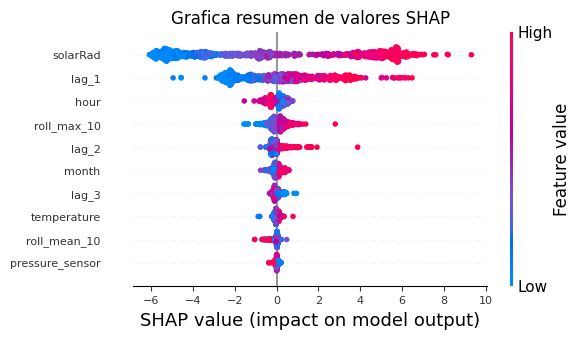

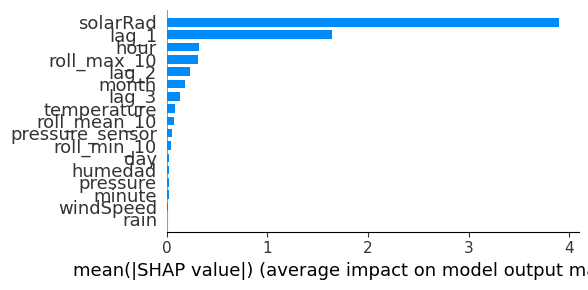

In [18]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

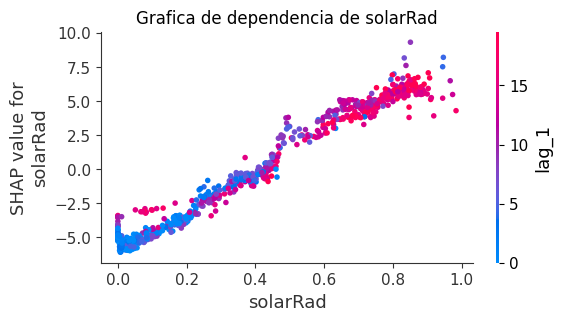

In [19]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Ahora veremos las explicaciones de SHAP para predicciones de las proximas 366 muestras (data_test)

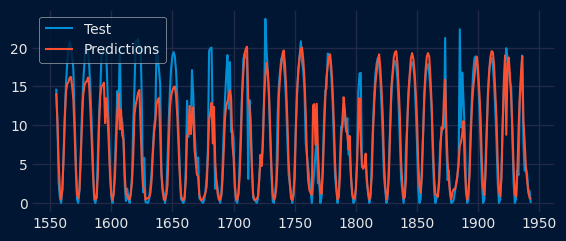

In [20]:
pred = forecaster.predict(steps=len(test_scaled), exog=test_scaled[exogenas])
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
test_scaled['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Graficas de dependencia parcial.

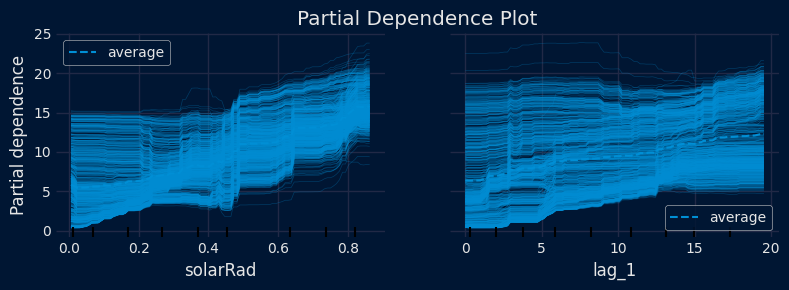

In [21]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [22]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.8600
Mean Squared Error (MSE): 7.9893
Root Mean Squared Error (RMSE): 2.8265
Coeficiente de determinación (R^2): 0.8354


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [23]:
t_min = data["hour"] * 60 + data["minute"]
t_day = 24 * 60

t_mid = 13 * 60   
x = abs((t_min - t_mid) / (t_day / 2))   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) 

IRR_MAX = 1002 #maxima solarRad en el dataset 
train_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm
test_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [24]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'pressure_sensor', 'month', 'day', 'hour', 'minute',
            'irr_ideal']

forecaster.fit(y=train_scaled["Power_gen"],
               exog=train_scaled[exogenas])

pred = forecaster.predict(steps=len(test_scaled),
                          exog=test_scaled[exogenas])

Nuevas métricas de la predicción, ligeramente mejores.

In [25]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.7726
Mean Squared Error (MSE): 7.6645
Root Mean Squared Error (RMSE): 2.7685
Coeficiente de determinación (R^2): 0.8421


Comparativa realidad vs prediccion

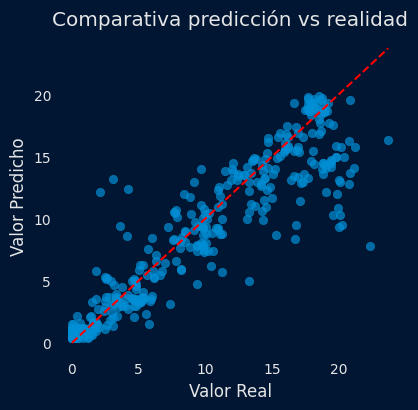

In [29]:
plt.figure(figsize=(4, 4))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()

Tratamiento de ceros

In [27]:
error_cero = np.where((y_test == 0) & (pred > mae))[0]

print(f"Se encontraron {len(error_cero)} errores mayores que el mae sen el valor cero")

print(pred.iloc[error_cero])
#pred.iloc[error_cero] = 0

Se encontraron 0 errores mayores que el mae sen el valor cero
Series([], Name: pred, dtype: float64)
